# Create a BTwin graph

This tutorial builds one small building knowledge graph from scratch, with synthetic data, and
then asks it questions. No LLM is involved anywhere: everything here is plain Python calls into
BTwin, `networkx`, and `matplotlib`.

**What we model** - a two-storey office, *Office Block A*:

```
bot:Building   Office Block A
|-- bot:Storey     Ground Floor
|   |-- bot:Space      Reception      + Pset + temperature sensor
|   `-- bot:Space      Meeting Room   + Pset + temperature & CO2 sensors + commissioning report
`-- bot:Storey     First Floor
    |-- bot:Space      Open Office    + Pset + temperature, CO2 & humidity sensors
    `-- bot:Space      Corridor       + Pset

brick:Zone     Thermal Zone North  <- Meeting Room, Open Office
btwin:KPISet   Energy & comfort, 2026 Q1  -> Office Block A
btwin:Document O&M manual                 -> Office Block A
```

**What you will end up with** - 22 nodes and 22 edges, serialized to JSON-LD, and an interactive
HTML page after every step so you can watch the graph grow. They land in `output/` as
`step-01-spatial.html` through `step-05-compacted.html`; open any of them in a browser.

**Prerequisites**

```bash
pip install "btwin[viz]"
```

Run the cells in order: later ones depend on objects built earlier.

In [1]:
from pathlib import Path
from collections import Counter
import json

import btwin
from btwin import (SpatialElement, PropertySet, Property, Point, Equipment,
                   KPISet, KPI, Document, Schema, Serialization,
                   NetworkX, GraphPlot)

from IPython.display import IFrame

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)

print("BTwin", btwin.__version__)

BTwin 0.5.6


Two helpers used throughout. `graphOf` turns whatever objects exist so far into a NetworkX graph,
and `show` draws one as a self-contained interactive page — click a node to inspect it, drag to
rearrange, use the legend to hide a class.

Every section below ends with one, so you can watch the graph grow step by step.

In [2]:
def graphOf(objects, name="Office Block A"):
    """Build a NetworkX graph from a list of BTwin objects: nodes first, then edges."""
    graph = NetworkX.Constructor("MultiDiGraph", name=name)
    for obj in objects:
        NetworkX.AddNodeByObject(graph, obj)
    for obj in objects:
        NetworkX.AddEdgesByObject(graph, obj)
    return graph


def show(graph, step, title, height=460):
    """Write the graph to output/<step>.html and embed it below the cell."""
    path = OUTPUT / f"step-{step}.html"
    GraphPlot.NetworkXByHTML(graph, savePath=str(path), title=title,
                             nodeGroupBy="type", edgeGroupBy="type")
    print(f"{title}: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges "
          f"-> {path}")
    return IFrame(src=str(path), width="100%", height=height)

## 1. Look up the vocabulary first

Every BTwin object carries an `@type` drawn from a controlled vocabulary (Brick, BOT, IFC).
Constructors reject a type they do not recognise, so it pays to look the list up before building
anything.

BTwin keeps a vocabulary per concern, and they nest rather than compete:

| Call | Covers | Used by |
|---|---|---|
| `Schema.Types()` | spatial and structural classes | `SpatialElement.Constructor` |
| `Point.Types()` | concrete Brick sensor/setpoint classes | `Point.Constructor` |
| `Equipment.Types()` | concrete Brick asset classes | `Equipment.Constructor` |
| `Serialization.IRIs()["classes"]` | everything that can be written to JSON-LD | `Serialization.JSONLDByObjects` |

The export vocabulary is the union of the others, so anything a constructor accepts can
also be serialized. That was not true before 0.5.5: `Serialization` declared 10 of
`Point`'s 54 types, so a perfectly valid sensor could fail at export time.

In [3]:
print("Spatial and structural types:")
for t in Schema.Types():
    print("   ", t)

Spatial and structural types:
    brick:Portfolio
    brick:Region
    brick:Zone
    brick:Energy_Zone
    brick:Fire_Zone
    bot:Site
    bot:Building
    bot:Storey
    bot:Space
    ifc:IfcPropertySet
    btwin:KPISet
    btwin:Document
    kpi:Scenario
    brick:Equipment
    brick:Point
    brick:System
    ifc:Sensor
    bot:Interface
    bot:Element
    top:Face
    top:Aperture


In [4]:
print("Relationship names:")
for r in Schema.RelationshipNames():
    print("   ", r)

Relationship names:
    brick:hasLocation
    brick:isFedBy
    bot:interfaceOf
    btwin:isAdjacentTo
    btwin:hasPassageTo
    btwin:isDocumentOf
    btwin:hasDocument
    kpi:relatedScenario
    ifc:HasPropertySets
    eko:hasAssociatedObject


In [5]:
exportable = set(Serialization.IRIs()["classes"])

print(f"Point.Types()      : {len(Point.Types())}")
print(f"Equipment.Types()  : {len(Equipment.Types())}")
print(f"exportable classes : {len(exportable)}")
print()
print("point types that cannot be exported     :",
      sorted(set(Point.Types()) - exportable) or "none")
print("equipment types that cannot be exported :",
      sorted(set(Equipment.Types()) - exportable) or "none")

Point.Types()      : 54
Equipment.Types()  : 93
exportable classes : 176

point types that cannot be exported     : none
equipment types that cannot be exported : none


Nothing is stranded, so you can pick any type the constructors accept and it will survive
section 7.

## 2. The spatial backbone

`SpatialElement.Constructor` returns a plain `dict` - that is the whole data model. There is no
hidden state and no database, so you can `print` any object at any point and see exactly what
BTwin will serialize.

In [6]:
building = SpatialElement.Constructor("bld-01", "bot:Building", "Office Block A")

print(json.dumps(building, indent=2))

{
  "@id": "bld-01",
  "@type": "bot:Building",
  "relationships": {},
  "name": "Office Block A"
}


`relationships` is empty because nothing has been wired yet. Let us make the rest of the elements.

In [7]:
storeyGround = SpatialElement.Constructor("storey-00", "bot:Storey", "Ground Floor")
storeyFirst = SpatialElement.Constructor("storey-01", "bot:Storey", "First Floor")

spaces = [
    SpatialElement.Constructor("space-01", "bot:Space", "Reception"),
    SpatialElement.Constructor("space-02", "bot:Space", "Meeting Room"),
    SpatialElement.Constructor("space-03", "bot:Space", "Open Office"),
    SpatialElement.Constructor("space-04", "bot:Space", "Corridor"),
]

zone = SpatialElement.Constructor("zone-01", "brick:Zone", "Thermal Zone North")

for element in [building, storeyGround, storeyFirst, *spaces, zone]:
    print(f"{SpatialElement.UID(element):<12} {SpatialElement.Type(element):<16} {element['name']}")

bld-01       bot:Building     Office Block A
storey-00    bot:Storey       Ground Floor
storey-01    bot:Storey       First Floor
space-01     bot:Space        Reception
space-02     bot:Space        Meeting Room
space-03     bot:Space        Open Office
space-04     bot:Space        Corridor
zone-01      brick:Zone       Thermal Zone North


### Wiring containment

`brick:hasLocation` points **from the child to its container**. `SetLocationRelationship` is the
shorthand for it, and it edits the object in place as well as returning it.

In [8]:
SpatialElement.SetLocationRelationship(storeyGround, linkedObject=building)
SpatialElement.SetLocationRelationship(storeyFirst, linkedObject=building)

# Reception and Meeting Room sit on the ground floor; Open Office and Corridor on the first.
for space, storey in zip(spaces, [storeyGround, storeyGround, storeyFirst, storeyFirst]):
    SpatialElement.SetLocationRelationship(space, linkedObject=storey)

print(json.dumps(spaces[0], indent=2))

{
  "@id": "space-01",
  "@type": "bot:Space",
  "relationships": {
    "brick:hasLocation": [
      {
        "@id": "storey-00",
        "@type": "bot:Storey"
      }
    ]
  },
  "name": "Reception"
}


A zone is a second, overlapping way to group spaces - it cuts across the storey hierarchy, which
is exactly why a graph suits this better than a tree. *Thermal Zone North* covers the Meeting Room
(ground) and the Open Office (first).

In [9]:
for space in (spaces[1], spaces[2]):
    SpatialElement.SetRelationship(space, "brick:hasLocation", linkedObject=zone)

print("Meeting Room is located in:")
for target in SpatialElement.Relationships(spaces[1])["brick:hasLocation"]:
    print("   ", target["@id"], f"({target['@type']})")

Meeting Room is located in:
    storey-00 (bot:Storey)
    zone-01 (brick:Zone)


In [10]:
spatial = [building, storeyGround, storeyFirst, zone, *spaces]

show(graphOf(spatial), "01-spatial", "Step 1 - spatial backbone")

Step 1 - spatial backbone: 8 nodes, 8 edges -> output\step-01-spatial.html


Two containers on one node. Nothing in BTwin forces a single parent. Zoom in on Meeting Room and
you can see both `brick:hasLocation` edges leaving it.

## 3. Property sets

A `PropertySet` groups IFC-style properties under its own UID and becomes its own node in the
graph, linked to its owner by `ifc:HasPropertySets`. Each `Property` carries a value, an IFC
quantity type, and a unit.

In [11]:
areas = {"space-01": 42.0, "space-02": 28.5, "space-03": 96.0, "space-04": 18.0}
uses = {"space-01": "reception", "space-02": "meeting",
        "space-03": "office", "space-04": "circulation"}

psets = []
for space in spaces:
    uid = SpatialElement.UID(space)
    pset = PropertySet.Constructor(f"pset-{uid}", "Pset_SpaceCommon")
    PropertySet.SetProperties(pset, [
        Property.Constructor("netFloorArea", areas[uid], None,
                             "IfcQuantityArea", "IfcPropertySingleValue", "sqm"),
        Property.Constructor("occupancyType", uses[uid], None,
                             "IfcLabel", "IfcPropertySingleValue", None),
    ])
    SpatialElement.SetPSetRelationship(space, pset=pset)
    psets.append(pset)

print(json.dumps(psets[1], indent=2))

{
  "@id": "pset-space-02",
  "@type": "ifc:IfcPropertySet",
  "name": "Pset_SpaceCommon",
  "ifc:HasProperties": [
    {
      "@type": "IfcPropertySingleValue",
      "name": "netFloorArea",
      "nominalValue": {
        "type": "IfcQuantityArea",
        "value": 28.5,
        "unit": "sqm"
      }
    },
    {
      "@type": "IfcPropertySingleValue",
      "name": "occupancyType",
      "nominalValue": {
        "type": "IfcLabel",
        "value": "meeting",
        "unit": null
      }
    }
  ]
}


In [12]:
# Read a single property back out of a set
area = PropertySet.Property(psets[1], "netFloorArea")

print("value :", Property.Value(area))
print("type  :", Property.QuantityType(area))
print("unit  :", Property.Unit(area))

value : 28.5
type  : IfcQuantityArea
unit  : sqm


In [13]:
show(graphOf([*spatial, *psets]), "02-psets", "Step 2 - property sets attached")

Step 2 - property sets attached: 12 nodes, 12 edges -> output\step-02-psets.html


Four new dark-red nodes, one per space, each on the end of an `ifc:HasPropertySets` edge.

## 4. Sensors

Sensors are `Point` objects. They are placed with the same `brick:hasLocation` predicate used for
spatial containment - a sensor is *located in* a space just as a space is *located in* a storey.

In [14]:
byUID = {SpatialElement.UID(o): o
         for o in [building, storeyGround, storeyFirst, zone, *spaces]}

sensorSpec = [
    ("pt-t-01", "brick:Temperature_Sensor", "Reception air temperature",     "space-01"),
    ("pt-t-02", "brick:Temperature_Sensor", "Meeting Room air temperature",  "space-02"),
    ("pt-c-01", "brick:CO2_Sensor",         "Meeting Room CO2",              "space-02"),
    ("pt-t-03", "brick:Temperature_Sensor", "Open Office air temperature",   "space-03"),
    ("pt-c-02", "brick:CO2_Sensor",         "Open Office CO2",               "space-03"),
    ("pt-h-01", "brick:Humidity_Sensor",    "Open Office relative humidity", "space-03"),
    ("pt-e-01", "brick:Energy_Sensor",      "Whole-building electricity",    "bld-01"),
]

points = []
for uid, pointType, name, hostUID in sensorSpec:
    point = Point.Constructor(uid, pointType, name)
    Point.SetRelationship(point, "brick:hasLocation", linkedObject=byUID[hostUID])
    points.append(point)
    print(f"{uid:<9} {pointType:<27} -> {byUID[hostUID]['name']}")

pt-t-01   brick:Temperature_Sensor    -> Reception
pt-t-02   brick:Temperature_Sensor    -> Meeting Room
pt-c-01   brick:CO2_Sensor            -> Meeting Room
pt-t-03   brick:Temperature_Sensor    -> Open Office
pt-c-02   brick:CO2_Sensor            -> Open Office
pt-h-01   brick:Humidity_Sensor       -> Open Office
pt-e-01   brick:Energy_Sensor         -> Office Block A


In [15]:
print(json.dumps(points[2], indent=2))

{
  "@id": "pt-c-01",
  "@type": "brick:CO2_Sensor",
  "relationships": {
    "brick:hasLocation": [
      {
        "@id": "space-02",
        "@type": "bot:Space"
      }
    ]
  },
  "name": "Meeting Room CO2"
}


In [16]:
show(graphOf([*spatial, *psets, *points]), "03-sensors", "Step 3 - sensors placed")

Step 3 - sensors placed: 19 nodes, 19 edges -> output\step-03-sensors.html


## 5. A KPI set

A `KPISet` bundles several KPIs evaluated over one time interval and attaches them to an object -
here, the building as a whole.

Two ordering details that are easy to get wrong:

- `SetKPIsTimestep` copies the set's interval down onto every KPI, so call it **after** all the
  KPIs are in.
- Each KPI keeps its own `eko:hasAssociatedObject` slot, which stays `null`. The association lives
  on the **set**, not on the individual KPI.

In [17]:
kpiSet = KPISet.Constructor(
    "kpiset-2026Q1",
    "Energy & comfort, 2026 Q1",
    hasBeginning="2026-01-01T00:00:00Z",
    hasEnd="2026-03-31T23:59:59Z",
)

for uid, name, value, unit in [
    ("kpi-eui",     "Energy use intensity",      31.4,  "kWh/sqm"),
    ("kpi-co2",     "Mean CO2 concentration",    742.0, "ppm"),
    ("kpi-comfort", "Hours within comfort band", 1683,  "h"),
]:
    KPISet.SetKPI(kpiSet, KPI.Constructor(uid, name, value, kpiUnit=unit))

KPISet.SetKPIsTimestep(kpiSet)
KPISet.SetAssociatedObject(kpiSet, linkedObject=building)

for uid, kpi in kpiSet["btwin:hasKPIs"].items():
    print(f"{uid:<13} {KPI.Name(kpi):<27} {KPI.Value(kpi)}")

kpi-eui       Energy use intensity        31.4
kpi-co2       Mean CO2 concentration      742.0
kpi-comfort   Hours within comfort band   1683


In [18]:
print("Evaluated over:", json.dumps(KPI.Timestep(kpiSet["btwin:hasKPIs"]["kpi-eui"]), indent=2))
print("Attached to   :", kpiSet["relationships"]["eko:hasAssociatedObject"])

Evaluated over: {
  "time:hasBeginning": "2026-01-01T00:00:00Z",
  "time:hasEnd": "2026-03-31T23:59:59Z"
}
Attached to   : [{'@id': 'bld-01', '@type': 'bot:Building'}]


## 6. Documents

A `Document` stands for a real file - a manual, a report, a certificate - and points at whatever
it describes with `btwin:isDocumentOf`.

In [19]:
manual = Document.Constructor("doc-01", "O&M manual, AHU-1")
Document.SetRelationship(manual, "btwin:isDocumentOf", linkedObject=building)

report = Document.Constructor("doc-02", "Commissioning report, Meeting Room")
Document.SetRelationship(report, "btwin:isDocumentOf", linkedObject=spaces[1])

for doc in (manual, report):
    target = Document.Relationships(doc)["btwin:isDocumentOf"][0]
    print(f"{Document.UID(doc):<8} {Document.Name(doc):<38} -> {target['@id']}")

doc-01   O&M manual, AHU-1                      -> bld-01
doc-02   Commissioning report, Meeting Room     -> space-02


In [20]:
show(graphOf([*spatial, *psets, *points, kpiSet, manual, report]),
     "04-complete", "Step 4 - complete model", height=520)

Step 4 - complete model: 22 nodes, 22 edges -> output\step-04-complete.html


That is the whole model: 22 nodes and 22 edges.

## 7. Serialize the whole model to JSON-LD

Everything built so far is a loose collection of dicts. `Serialization.JSONLDByObjects` gathers
them into one JSON-LD document with a shared `@context`, validating every class as it goes.

`savePath` always lands on a `.json` extension - the serializer rewrites anything else.

In [21]:
allObjects = [building, storeyGround, storeyFirst, zone,
              *spaces, *psets, *points, kpiSet, manual, report]

jsonld = Serialization.JSONLDByObjects(allObjects, savePath=OUTPUT / "office-block-a.json")

print("top-level keys :", list(jsonld.keys()))
print("@graph entries :", len(jsonld["@graph"]))
print("prefixes       :", ", ".join(sorted(jsonld["@context"])[:8]), "...")

top-level keys : ['@context', '@graph']
@graph entries : 22
prefixes       : bot, brick, btwin, eko, ifc, time ...


## 8. Build the graph

Two passes: add every object as a node first, then add the edges. Doing nodes first means every
edge finds both endpoints already present.

In [22]:
G = NetworkX.Constructor("MultiDiGraph", name="Office Block A")

for obj in allObjects:
    NetworkX.AddNodeByObject(G, obj)
for obj in allObjects:
    NetworkX.AddEdgesByObject(G, obj)

print(f"nodes: {G.number_of_nodes()}   edges: {G.number_of_edges()}")

nodes: 22   edges: 22


In [23]:
print("Nodes by type")
for nodeType, count in Counter(d.get("type") for _, d in G.nodes(data=True)).most_common():
    print(f"   {count:>2}  {nodeType}")

print()
print("Edges by relationship")
for edgeType, count in Counter(d.get("type") for _, _, d in G.edges(data=True)).most_common():
    print(f"   {count:>2}  {edgeType}")

Nodes by type
    4  bot:Space
    4  ifc:IfcPropertySet
    3  brick:Temperature_Sensor
    2  bot:Storey
    2  brick:CO2_Sensor
    2  btwin:Document
    1  bot:Building
    1  brick:Zone
    1  brick:Humidity_Sensor
    1  brick:Energy_Sensor
    1  btwin:KPISet

Edges by relationship
   15  brick:hasLocation
    4  ifc:HasPropertySets
    2  btwin:isDocumentOf
    1  eko:hasAssociatedObject


In [24]:
# Anything that ended up unreachable is almost always a wiring mistake.
print("isolated nodes:", NetworkX.IsolatedNodes(G) or "none")

isolated nodes: none


## 9. Ask the graph questions

This is the point of building it. A few of the helpers on `NetworkX`:

In [25]:
# Q: what touches the Meeting Room?
print("Directly linked to space-02 (Meeting Room):")
for uid in NetworkX.NodeLinkedNodes(G, "space-02"):
    print(f"   {uid:<15} {G.nodes[uid].get('type',''):<27} {G.nodes[uid].get('name','')}")

Directly linked to space-02 (Meeting Room):
   storey-00       bot:Storey                  Ground Floor
   zone-01         brick:Zone                  Thermal Zone North
   pset-space-02   ifc:IfcPropertySet          Pset_SpaceCommon
   pt-t-02         brick:Temperature_Sensor    Meeting Room air temperature
   pt-c-01         brick:CO2_Sensor            Meeting Room CO2
   doc-02          btwin:Document              Commissioning report, Meeting Room


In [26]:
# Q: what are the Meeting Room's properties?
for psetUID, attrs in NetworkX.NodeLinkedPSets(G, "space-02"):
    print(f"{psetUID}  ({attrs['name']})")
    for key in ("netFloorArea", "occupancyType"):
        print(f"   {key:<15} {attrs[key]}")

pset-space-02  (Pset_SpaceCommon)
   netFloorArea    28.5
   occupancyType   meeting


In [27]:
# Q: where are all the CO2 sensors?
print("CO2 sensors and the space they serve:")
for uid, attrs in G.nodes(data=True):
    if attrs.get("type") == "brick:CO2_Sensor":
        host = NetworkX.NodeLinkedNodes(G, uid)[0]
        print(f"   {uid:<9} {attrs['name']:<32} -> {G.nodes[host]['name']}")

CO2 sensors and the space they serve:
   pt-c-01   Meeting Room CO2                 -> Meeting Room
   pt-c-02   Open Office CO2                  -> Open Office


In [28]:
# Q: what does the pure spatial skeleton look like, with sensors and paperwork stripped out?
spatialOnly = NetworkX.SubgraphByObjectTypes(
    G, objectTypes=["bot:Building", "bot:Storey", "bot:Space", "brick:Zone"])

print(f"spatial subgraph: {spatialOnly.number_of_nodes()} nodes, "
      f"{spatialOnly.number_of_edges()} edges")
for source, target, data in spatialOnly.edges(data=True):
    print(f"   {G.nodes[source]['name']:<14} --{data['type']}--> {G.nodes[target]['name']}")

spatial subgraph: 8 nodes, 8 edges
   Corridor       --brick:hasLocation--> First Floor
   Ground Floor   --brick:hasLocation--> Office Block A
   First Floor    --brick:hasLocation--> Office Block A
   Meeting Room   --brick:hasLocation--> Ground Floor
   Meeting Room   --brick:hasLocation--> Thermal Zone North
   Reception      --brick:hasLocation--> Ground Floor
   Open Office    --brick:hasLocation--> First Floor
   Open Office    --brick:hasLocation--> Thermal Zone North


### Flattening property sets

`CompactPSets` folds each property set's values onto its owner node and drops the separate pset
node. That makes attribute lookups trivial at the cost of losing the pset grouping.

**It rewrites the graph in place**, so work on a copy if you still need the original - which we do,
for the plots below.

In [29]:
compact = NetworkX.CompactPSets(G.copy())

print(f"before: {G.number_of_nodes()} nodes   after: {compact.number_of_nodes()} nodes")
print()
print(json.dumps(compact.nodes["space-02"], indent=2))

{'psetsFound': 4, 'psetsCompacted': 4, 'psetsOrphanDeleted': 0, 'ownersTouched': 4, 'propertiesAttached': 8, 'conflicts': 0}
before: 22 nodes   after: 18 nodes

{
  "id": "space-02",
  "type": "bot:Space",
  "name": "Meeting Room",
  "netFloorArea": 28.5,
  "occupancyType": "meeting"
}


## 10. Draw it

`GraphPlot.NetworkXByMatplotlib` colours nodes by `type` and edges by relationship, and returns
the usual `(fig, ax)` pair.

Drawn graph with 22 nodes and 22 edges.


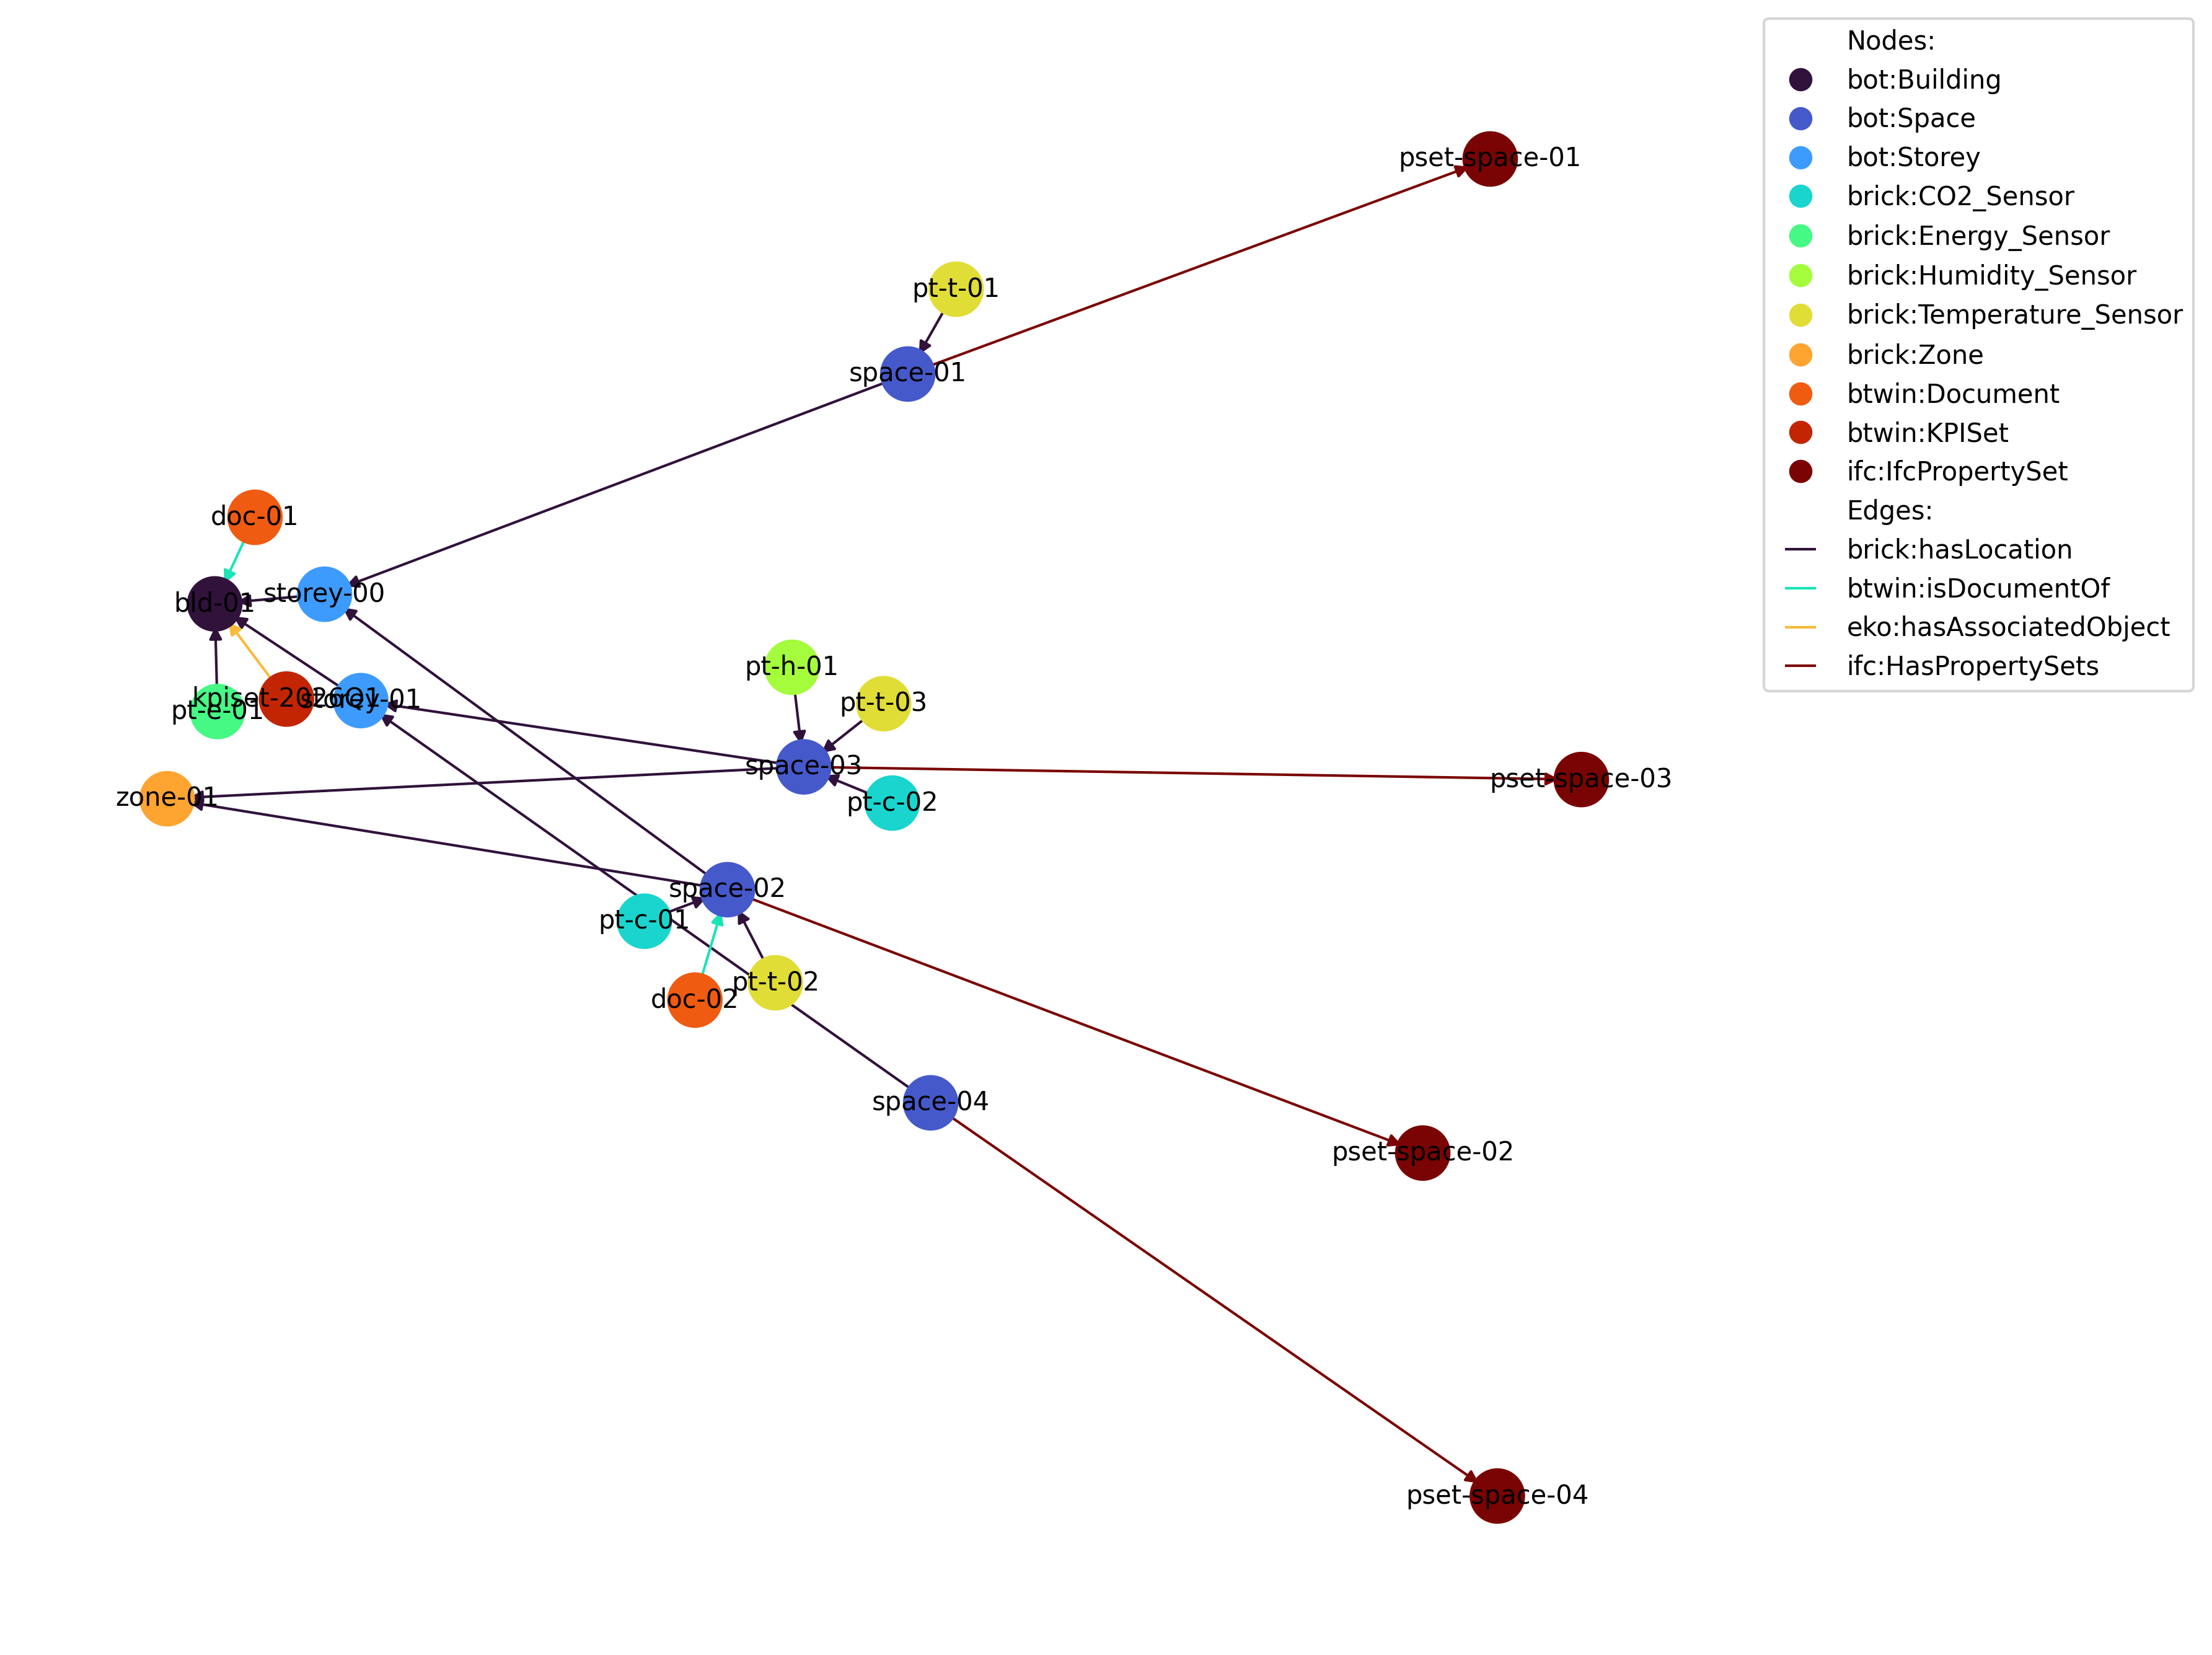

In [30]:
%matplotlib inline

fig, ax = GraphPlot.NetworkXByMatplotlib(
    G,
    showNodeLabels=True,
    showEdgeLabels=False,
    nodeSize=420,
    figsize=(12, 9),
    layout="spring",
    layoutSeed=26,
    savePath=str(OUTPUT / "office-block-a.png"),
)

The static figure is fine for a report, but hard to read past a few dozen nodes — which is why
every step above also produced an interactive page. Here is the flattened graph from section 9,
side by side in your head with step 4: same building, four fewer nodes, the property values now
sitting on the spaces themselves.

In [31]:
show(compact, "05-compacted", "Step 5 - property sets folded in", height=520)

Step 5 - property sets folded in: 18 nodes, 18 edges -> output\step-05-compacted.html


## 11. Validating the graph

`NetworkX.Validate` checks every node type and every edge predicate against the vocabulary, prints
a summary, and **returns a report** you can act on.

In [32]:
report = NetworkX.Validate(G)

print()
print("ok           :", report["ok"])
print("nodes checked:", report["counts"]["nodesChecked"])
print("edges checked:", report["counts"]["edgesChecked"])

✓ NetworkX validation passed (all node/edge types are valid).

ok           : True
nodes checked: 22
edges checked: 22


The report is a dict, so failures are machine-readable rather than something you have to scrape
from stdout. Feed it a node type that does not exist and you get the offender back:

In [33]:
broken = G.copy()
broken.add_node("mystery-01", type="brick:Not_A_Real_Class", name="Mystery")

brokenReport = NetworkX.Validate(broken, printReport=False)

print("ok:", brokenReport["ok"])
for entry in brokenReport["invalidNodes"]:
    print(f"   {entry['id']}: {entry['foundType']} - {entry['reason']}")

ok: False
   mystery-01: brick:Not_A_Real_Class - Node type not found in schema Types()


Two things here changed recently, and both are worth knowing if you used an earlier version:

- `Validate` used to **return the graph** rather than the report, so the `invalidNodes` list it
  builds was unreachable, and `ByJSONLD(..., haltOnInvalid=True)` raised `AttributeError` instead
  of failing cleanly. Fixed in 0.5.5.
- It also checked node types against `Schema.Types()` alone, which stops at `brick:Point` and
  `brick:Equipment`, so every concrete sensor and every asset reported as invalid. Since 0.5.6 it
  validates against the **export vocabulary** — `Serialization.IRIs()["classes"]`, the same list
  from section 1 — so the rule is simply that anything BTwin can serialize, it can also validate.

## Questions to try

The graph is small enough to check every answer by hand, which makes it a good place to practise.

1. **Which storey has more sensors?** Walk each `brick:*_Sensor` node up two `brick:hasLocation`
   hops and count by storey. (Careful: the Meeting Room has *two* containers.)
2. **What is the total net floor area per storey?** Use `NetworkX.NodeLinkedPSets` on each space,
   or flatten with `CompactPSets` first and read `netFloorArea` straight off the node.
3. **Which spaces have no documentation?** Compare the set of `bot:Space` nodes against the
   targets of every `btwin:isDocumentOf` edge.
4. **Add an equipment item.** Build an air handling unit with `Equipment.Constructor`, place it
   with `SetLocationRelationship`, and feed the Meeting Room with `SetFeedingRelationship`. Then
   re-run section 8 and watch the new node appear.

## Where to go next

- [`../02-graph-formats/`](../02-graph-formats/graph-formats.ipynb) - move this graph between
  JSON-LD, NetworkX, RDF and Neo4j.
- [`../00-early-adopters/`](../00-early-adopters/early-adopters.ipynb) - a method-by-method reference walkthrough
  of the whole API.
- `NetworkX.ToRDF` and `RDF.Query` - turn this graph into an rdflib graph and query it with
  SPARQL (needs `pip install "btwin[rdf]"`).
- `Observation.SQLiteByDF` - attach real time series to the sensor points built in section 4.
- `NetworkX.ToNEO4J` - push the same graph into Neo4j.